## Handling Imbalanced Dataset

1. Upsampling
2. Downsampling

In [4]:
import numpy as np
import pandas as pd

In [5]:
np.random.seed(123) # seed for reproducibility

## creating dataframes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [6]:
n_class_0, n_class_1

(900, 100)

## Creating a dataframe with imbalance dataset

In [7]:
class_0 = pd.DataFrame({
    'feature_1':np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2':np.random.normal(loc=0, scale=1, size=n_class_0),
    'target':[0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1':np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2':np.random.normal(loc=0, scale=1, size=n_class_1),
    'target':[1] * n_class_1
})

In [8]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)

In [9]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [10]:
df.tail()

,feature_1,feature_2,target
995,-0.623629,0.845701,1
996,0.239810,-1.119923,1
997,-0.868240,-0.359297,1
998,0.902006,-1.609695,1
999,0.697490,0.013570,1


In [11]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

### Upsampling

In [12]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [13]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority,replace=True,
                                n_samples=len(df_majority),
                                random_state=42
                                )

In [14]:
df_minority_upsampled.shape

(900, 3)

In [15]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,-0.874146,-0.156083,1
992,0.196570,-0.602575,1
914,-0.067830,0.998053,1
971,0.272825,1.034197,1
960,0.870056,-0.449515,1


In [16]:
df_upsampled=pd.concat([df_majority, df_minority_upsampled])

In [17]:
df_upsampled

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
952,-0.811098,0.189189,1
965,1.919526,-0.019459,1
976,0.810326,1.604614,1
942,1.621531,0.168229,1


In [18]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## Creating a dataframe with imbalanced dataset

In [19]:


class_0 = pd.DataFrame({
    'feature_1':np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2':np.random.normal(loc=0, scale=1, size=n_class_0),
    'target':[0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1':np.random.normal(loc=0, scale=1, size=n_class_1),
    'feature_2':np.random.normal(loc=0, scale=1, size=n_class_1),
    'target':[1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

### Downsampling

In [20]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [21]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority,replace=False,
                                n_samples=len(df_minority),
                                random_state=42
                                )

In [22]:
df_majority_downsampled

,feature_1,feature_2,target
70,0.786057,0.830076,0
827,-0.859775,0.174732,0
231,-0.012870,-0.735348,0
588,-0.297331,-0.351224,0
39,0.528702,1.508257,0
...,...,...,...
398,1.013666,0.083496,0
76,0.164480,-1.808980,0
196,-1.576624,0.525893,0
631,-0.540147,0.610282,0


In [23]:
df_majority_downsampled.shape

(100, 3)

In [24]:
df_downsampled=pd.concat([df_minority, df_majority_downsampled])

In [25]:
df_downsampled

,feature_1,feature_2,target
900,-2.643425,0.571923,1
901,-0.448991,-0.217233,1
902,-0.358907,0.054318,1
903,0.133194,0.155998,1
904,-0.644242,0.467810,1
...,...,...,...
398,1.013666,0.083496,0
76,0.164480,-1.808980,0
196,-1.576624,0.525893,0
631,-0.540147,0.610282,0


In [26]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

# SMOTE

In [1]:
from sklearn.datasets import make_classification

In [2]:
x,y=make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1,
                    weights=[0.90], random_state=12)

In [3]:
import pandas as pd

df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1,df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [4]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

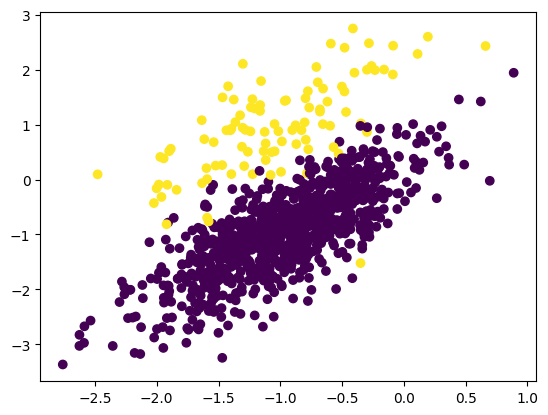

In [5]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [6]:
!pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---

In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
## transfrom dataset
oversample = SMOTE()
x,y = oversample.fit_resample(final_df[['f1', 'f2',]], final_df['target'])

In [11]:
x.shape

(1800, 2)

In [12]:
y.shape

(1800,)

In [13]:
y==0

0        True
1        True
2        True
3       False
4        True
        ...  
1795    False
1796    False
1797    False
1798    False
1799    False
Name: target, Length: 1800, dtype: bool

In [14]:
y[y==0]

0      0
1      0
2      0
4      0
5      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: target, Length: 900, dtype: int64

In [15]:
len(y[y==0])

900

In [16]:
len(y[y==1])

900

In [18]:
df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
oversample_df = pd.concat([df1,df2], axis=1)

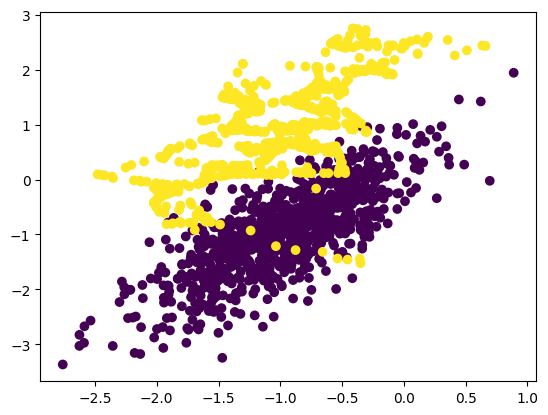

In [19]:
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])